# EDA — Healthcare Provider Fraud Detection

Análisis exploratorio del dataset `rohitrox/healthcare-provider-fraud-detection-analysis`.  
Objetivo: entender la estructura de los datos, el desbalance de clases y los patrones de fraude.

In [2]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from healthcare_fraud.data import clean_dataframe, load_dataset, validate_dataframe

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## 1. Carga de datos

In [3]:
# Carga y validación de todas las tablas
dfs_raw = load_dataset()
print("Tablas disponibles:", list(dfs_raw.keys()))

Dataset URL: https://www.kaggle.com/datasets/rohitrox/healthcare-provider-fraud-detection-analysis


100%|████████████████████████████████████████████████████████████████████| 25.4M/25.4M [00:04<00:00, 5.41MB/s]


Unrecognized CSV filename: Test_Beneficiarydata-1542969243754.csv — skipped
Unrecognized CSV filename: Test_Inpatientdata-1542969243754.csv — skipped
Unrecognized CSV filename: Test_Outpatientdata-1542969243754.csv — skipped


Tablas disponibles: ['labels_test', 'labels_train', 'beneficiary', 'inpatient', 'outpatient']


In [4]:
# Validar y limpiar cada tabla
dfs = {}
for name, df in dfs_raw.items():
    validated = validate_dataframe(df, name)
    dfs[name] = clean_dataframe(validated, name)

# Resumen de dimensiones
summary = pd.DataFrame(
    [(k, *v.shape) for k, v in dfs.items()], columns=["tabla", "filas", "columnas"]
)
summary

[outpatient] High null percentage: 57.90%


,tabla,filas,columnas
0,labels_test,1353,1
1,labels_train,5410,2
2,beneficiary,138556,24
3,inpatient,40474,23
4,outpatient,517737,14


## 2. Estructura de cada tabla

In [5]:
for name, df in dfs.items():
    print(f"\n### {name} ###")
    display(df.dtypes.to_frame("dtype").T)
    display(df.head(2))


### labels_test ###


,Provider
dtype,object


,Provider
0,PRV51002
1,PRV51006



### labels_train ###


,Provider,PotentialFraud
dtype,object,int64


...

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,AdmissionDt,ClmAdmitDiagnosisCode,...,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmProcedureCode_1
dtype,object,object,datetime64[ns],datetime64[ns],object,float32,object,object,datetime64[ns],object,...,object,object,object,object,object,object,object,object,object,float64


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,AdmissionDt,ClmAdmitDiagnosisCode,...,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmProcedureCode_1
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000.0,PHY390922,NaN,2009-04-12,7866,...,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000.0,PHY318495,PHY318495,2009-08-31,6186,...,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,7092.0



### outpatient ###


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,DeductibleAmtPaid,ClmAdmitDiagnosisCode
dtype,object,object,datetime64[ns],datetime64[ns],object,float32,object,object,object,object,object,object,float32,object


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30.0,PHY326117,NaN,78943,V5866,V1272,NaN,0.0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80.0,PHY362868,NaN,6115,NaN,NaN,NaN,0.0,79380


## 3. Desbalance de clases (variable objetivo)

Proveedores totales: 5,410
Fraude (1): 506  |  No fraude (0): 4,904
Ratio de fraude: 9.35%


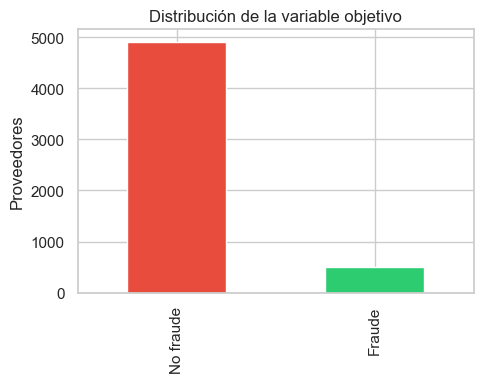

In [6]:
labels = dfs.get("labels_train")
if labels is not None and "PotentialFraud" in labels.columns:
    counts = labels["PotentialFraud"].value_counts()
    ratio = counts[1] / len(labels) * 100
    print(f"Proveedores totales: {len(labels):,}")
    print(f"Fraude (1): {counts.get(1, 0):,}  |  No fraude (0): {counts.get(0, 0):,}")
    print(f"Ratio de fraude: {ratio:.2f}%")

    fig, ax = plt.subplots(figsize=(5, 4))
    counts.rename({1: "Fraude", 0: "No fraude"}).plot.bar(ax=ax, color=["#e74c3c", "#2ecc71"])
    ax.set_title("Distribución de la variable objetivo")
    ax.set_xlabel("")
    ax.set_ylabel("Proveedores")
    plt.tight_layout()
    plt.show()

## 4. Distribuciones de montos de reclamación

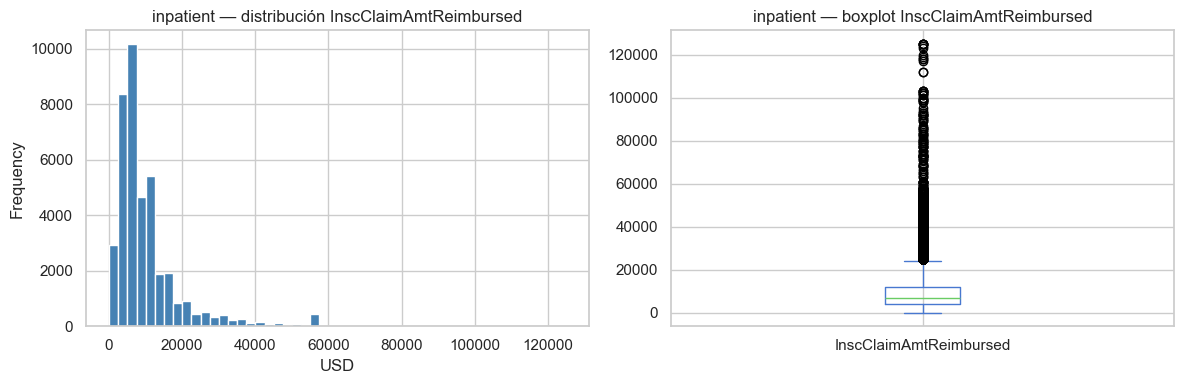

count     40474.000000
mean      10087.883789
std       10303.099609
min           0.000000
25%        4000.000000
50%        7000.000000
75%       12000.000000
max      125000.000000


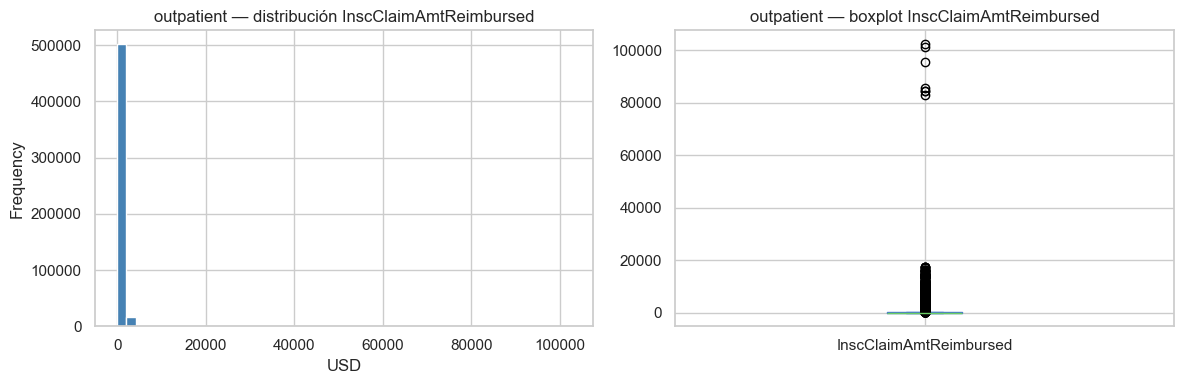

count    517737.000000
mean        286.334778
std         694.034363
min           0.000000
25%          40.000000
50%          80.000000
75%         200.000000
max      102500.000000


In [7]:
amount_col = "InscClaimAmtReimbursed"

for table_name in ("inpatient", "outpatient"):
    df = dfs.get(table_name)
    if df is None or amount_col not in df.columns:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    df[amount_col].dropna().plot.hist(bins=50, ax=axes[0], color="steelblue")
    axes[0].set_title(f"{table_name} — distribución {amount_col}")
    axes[0].set_xlabel("USD")

    df[amount_col].dropna().plot.box(ax=axes[1])
    axes[1].set_title(f"{table_name} — boxplot {amount_col}")
    plt.tight_layout()
    plt.show()

    print(df[amount_col].describe().to_string())

## 5. Análisis de nulos por columna

labels_test: sin nulos
labels_train: sin nulos
beneficiary: sin nulos


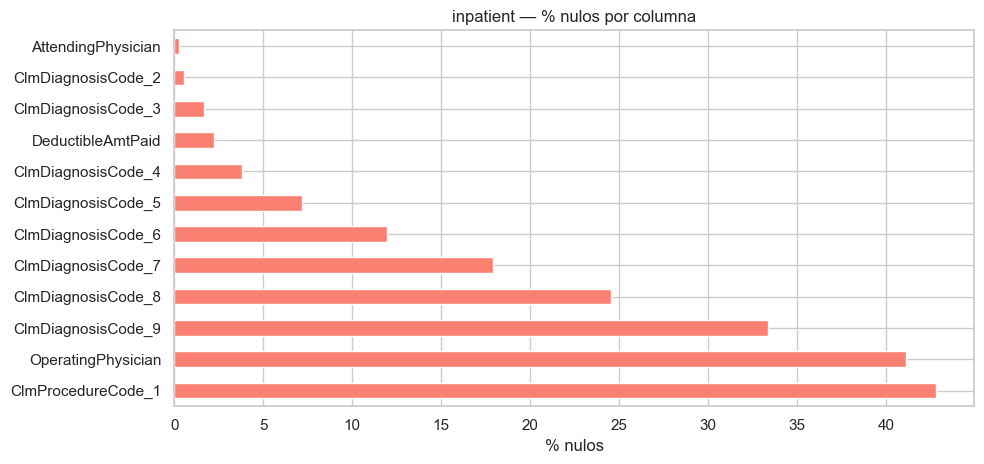

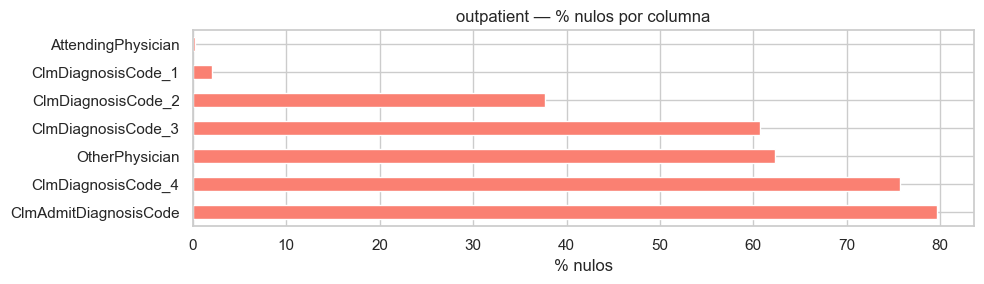

In [8]:
for name, df in dfs.items():
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        print(f"{name}: sin nulos")
        continue

    fig, ax = plt.subplots(figsize=(10, max(3, len(null_pct) * 0.4)))
    null_pct.plot.barh(ax=ax, color="salmon")
    ax.set_title(f"{name} — % nulos por columna")
    ax.set_xlabel("% nulos")
    plt.tight_layout()
    plt.show()

## 6. Heatmap de correlaciones (inpatient)

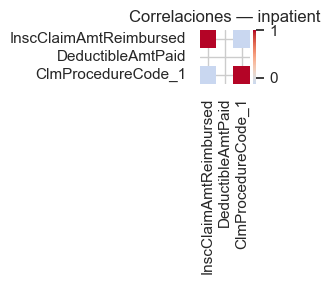

In [9]:
df_ip = dfs.get("inpatient")
if df_ip is not None:
    numeric_cols = df_ip.select_dtypes(include="number").columns.tolist()
    if len(numeric_cols) > 1:
        corr = df_ip[numeric_cols].corr()
        fig, ax = plt.subplots(figsize=(min(14, len(numeric_cols)), min(12, len(numeric_cols))))
        sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Correlaciones — inpatient")
        plt.tight_layout()
        plt.show()

## 7. Distribución geográfica (beneficiary)

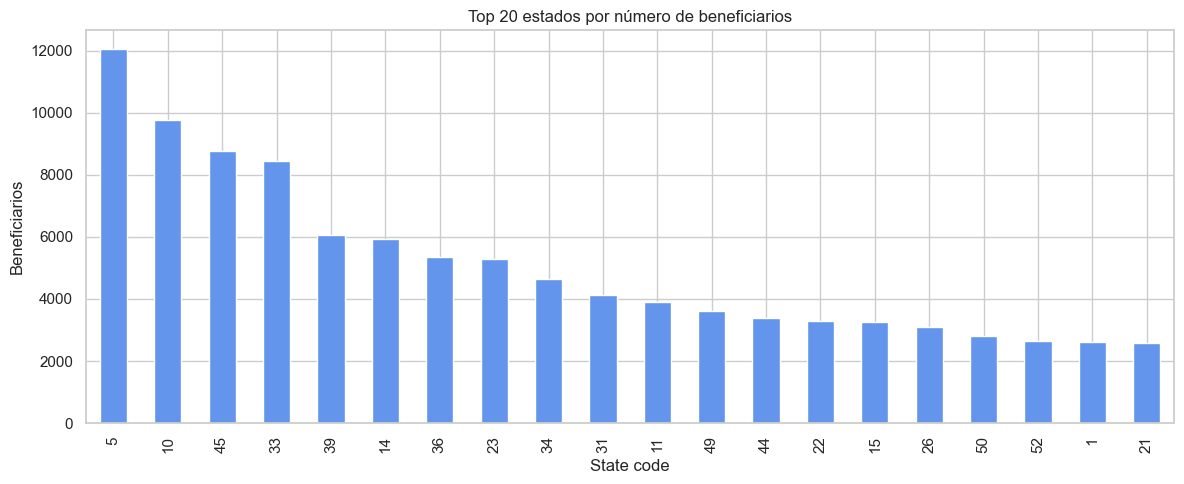

In [10]:
bene = dfs.get("beneficiary")
if bene is not None and "State" in bene.columns:
    top_states = bene["State"].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_states.plot.bar(ax=ax, color="cornflowerblue")
    ax.set_title("Top 20 estados por número de beneficiarios")
    ax.set_xlabel("State code")
    ax.set_ylabel("Beneficiarios")
    plt.tight_layout()
    plt.show()

## 8. Conclusiones

**Completar después de ejecutar el notebook con datos reales:**

- **Desbalance de clases**: ratio de fraude aproximado ~10% (confirmar con celda 3)
- **Tablas principales**: beneficiary (demografía), inpatient/outpatient (reclamaciones), labels_train (etiquetas por proveedor)
- **Variables discriminantes**: montos de reclamación, número de reclamaciones por proveedor, condiciones crónicas acumuladas
- **Calidad de datos**: columnas de diagnóstico secundario y procedimientos tienen alta tasa de nulos — candidatos a ingeniería de features agregadas
- **Siguiente paso**: construir features a nivel proveedor (Fase 02) agregando inpatient + outpatient + beneficiary